In [36]:
import os, sys, math, time, random
from typing import Tuple, Dict, Any, Callable, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

### Немного про torch

In [37]:
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

In [38]:
device

device(type='mps')

In [39]:
a = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32, requires_grad=True) 
b = torch.ones((2, 3), dtype=torch.int64)
z = torch.zeros_like(a)
r = torch.randn((2, 3))

print(a.dtype, b.dtype, z.shape, r.mean().item())

torch.float32 torch.int64 torch.Size([2, 3]) -0.07068530470132828


In [40]:
x = torch.tensor(5, dtype=torch.float32, requires_grad=True) 
w = torch.tensor(2, dtype=torch.float32, requires_grad=True) 

lr = torch.tensor(0.001, dtype=torch.float32)

In [41]:
#градиентный спуск с функционалом торча

for step in range(50):
    y = (x - w) ** 2
    y.backward()
    
    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()
    
print(x)

tensor(4.7142, requires_grad=True)


### Практика 2 (пайплайн тренировки МЛП)

In [42]:
# Практическое занятие по нейронным сетям в PyTorch
# Создадим и обучим многослойный перцептрон для бинарной классификации

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# Фиксируем случайные seed'ы для воспроизводимости
torch.manual_seed(42)  # Для PyTorch
np.random.seed(42)     # Для NumPy и scikit-learn


In [43]:
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
device

device(type='mps')

In [44]:
data = pd.read_csv('week2_practice.csv').drop("Unnamed: 32", axis=1)
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [45]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

X = data.drop(['id', 'diagnosis'], axis=1).to_numpy()
y = data['diagnosis'].to_numpy()

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# Создаем кастомный класс Dataset
# Необходим для интеграции с PyTorch
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)  # Должен возвращать размер датасета
    
    def __getitem__(self, idx):
        # Возвращает одну пару (признаки, метка) по индексу
        return self.features[idx], self.labels[idx]


# Создаем объекты Dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# Создаем DataLoader для батчевой обработки
BATCH_SIZE = 8  # Размер батча - гиперпараметр

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True  # Перемешиваем тренировочные данные каждый эпоху
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False  # Для теста перемешивание не нужно
)

In [47]:
# Проверка работы DataLoader
print(f"Количество батчей: {len(train_loader)}")

features_batch, labels_batch = next(iter(train_loader))
print(f"Размерность батча признаков: {features_batch.shape}")
print(f"Размерность батча меток: {labels_batch.shape}")

Количество батчей: 57
Размерность батча признаков: torch.Size([8, 30])
Размерность батча меток: torch.Size([8, 1])


In [48]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.lin1 = nn.Linear(input_size, hidden_size)
        self.act1 = nn.ReLU()
        self.lin2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        y1 = self.lin1(x)
        y2 = self.act1(y1)
        return self.lin2(y2)

# Инициализация модели
model = MLP(
    input_size=30,
    hidden_size=40,
    output_size=1
)

print(model)

MLP(
  (lin1): Linear(in_features=30, out_features=40, bias=True)
  (act1): ReLU()
  (lin2): Linear(in_features=40, out_features=1, bias=True)
)


In [49]:
# Функция потерь и оптимизатор
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Шедулер для уменьшения learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [50]:
# переводим модель на gpu
model.to(device)

MLP(
  (lin1): Linear(in_features=30, out_features=40, bias=True)
  (act1): ReLU()
  (lin2): Linear(in_features=40, out_features=1, bias=True)
)

 28%|██▊       | 7/25 [00:00<00:01, 12.45it/s]

Epoch 5/25 | Train Loss: 3.6090 | Val Loss: 3.8763 | LR: 0.010000


 44%|████▍     | 11/25 [00:00<00:01, 11.32it/s]

Epoch 10/25 | Train Loss: 4.3188 | Val Loss: 0.6509 | LR: 0.005000


 68%|██████▊   | 17/25 [00:01<00:00, 11.16it/s]

Epoch 15/25 | Train Loss: 0.5637 | Val Loss: 0.5699 | LR: 0.005000


 84%|████████▍ | 21/25 [00:01<00:00, 12.05it/s]

Epoch 20/25 | Train Loss: 0.5315 | Val Loss: 0.5467 | LR: 0.002500


100%|██████████| 25/25 [00:02<00:00, 11.47it/s]

Epoch 25/25 | Train Loss: 0.5369 | Val Loss: 0.5253 | LR: 0.002500


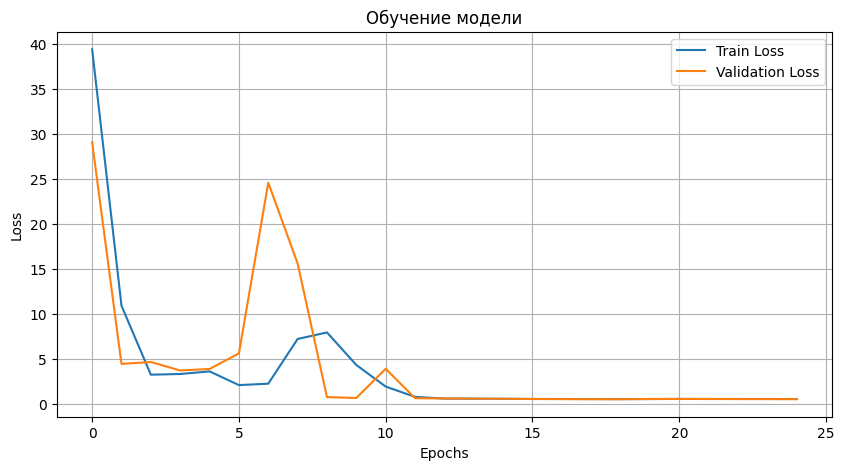

In [51]:
# Параметры обучения
EPOCHS = 25
train_losses = []
val_losses = []

for epoch in tqdm(range(EPOCHS)):
    # Режим обучения
    model.train() #переводим модель в режим тренировки
    running_loss = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad() #сбрасываем все градиенты
        
        #закидываем батч на GPU
        data = data.to(device)
        target = target.to(device)
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target) #считаем лосс
        
        # Backward pass
        loss.backward() #считаем градиенты
        optimizer.step() #обновляем веса
        
        running_loss += loss.item() 
    
    # Обновление learning rate после эпохи
    scheduler.step()
    
    # Средняя потеря за эпоху
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Валидация
    model.eval() #переводим модель в режим инференса
    val_loss = 0.0
    
    with torch.no_grad(): #Context-manager that disables gradient calculation.
        for data, target in test_loader:
            
            #закидываем батч на GPU
            data = data.to(device)
            target = target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    
    # Логирование
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {epoch_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

# График обучения
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Обучение модели')
plt.legend()
plt.grid(True)
plt.show()


Точность на тестовом наборе: 0.8596


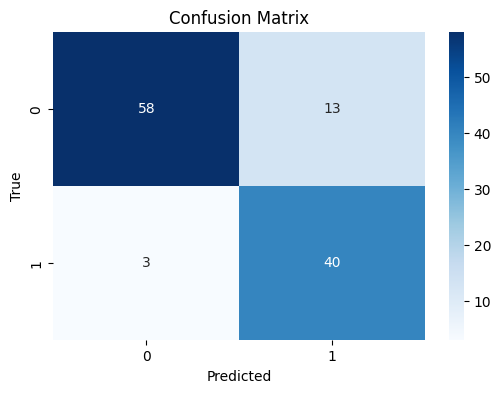

In [52]:
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for data, target in test_loader:
            
            data = data.to(device)
            target = target.to(device)
            
            outputs = model(data)
            predicted = (outputs > 0.5).float()  # Бинарная классификация
            
            y_true.extend(target.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Точность на тестовом наборе: {accuracy:.4f}")
    
    # Матрица ошибок
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_model(model, test_loader)